
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a **density-based clustering algorithm**.  
Instead of assuming clusters are spherical (like k-means), DBSCAN identifies clusters as **regions of high point density separated by sparse regions**.

---

# Key Idea

A cluster is defined as a **dense region of points**.  
Points in sparse regions are labeled as **noise (outliers)**.

DBSCAN therefore has two advantages compared with methods like k-means:

- It **does not require specifying the number of clusters in advance**
- It can **detect clusters with arbitrary shapes**

---

# Core Concepts

DBSCAN classifies points into three categories:

### 1. Core Points
A point is a **core point** if at least `min_samples` points lie within a radius `eps` from it.

Formally:

A point $x_i$ is a core point if

\begin{align*}
|N_\epsilon(x_i)| \geq \text{min\_samples}
\end{align*}

where  
$N_\epsilon(x_i)$ is the set of points within distance `eps`.

---

### 2. Border Points
Points that are **not core points** but lie within the `eps` neighborhood of a core point.

They belong to the cluster but do not have enough neighbors themselves.

---

### 3. Noise Points
Points that are **neither core points nor border points**.

These points are considered **outliers**.

---

# DBSCAN Parameters

DBSCAN has two key parameters:

### `eps`
The **radius of the neighborhood**.

Two points are neighbors if

$$
distance(x_i, x_j) \leq eps
$$

---

### `min_samples`

Minimum number of points required to form a **dense region**.

Typical interpretation:

- smaller `min_samples` → easier to form clusters  
- larger `min_samples` → clusters must be denser

Common rule of thumb:

```
min_samples ≈ 2 × number_of_features
```

---

# Advantages of DBSCAN

- Detects **arbitrary-shaped clusters**
- Identifies **noise / outliers**
- Does **not require specifying number of clusters**

---

# Limitations

DBSCAN can struggle when:

- cluster densities vary strongly
- data dimensionality is very high
- `eps` is difficult to choose

---

# Visualizing the Effect of Parameters


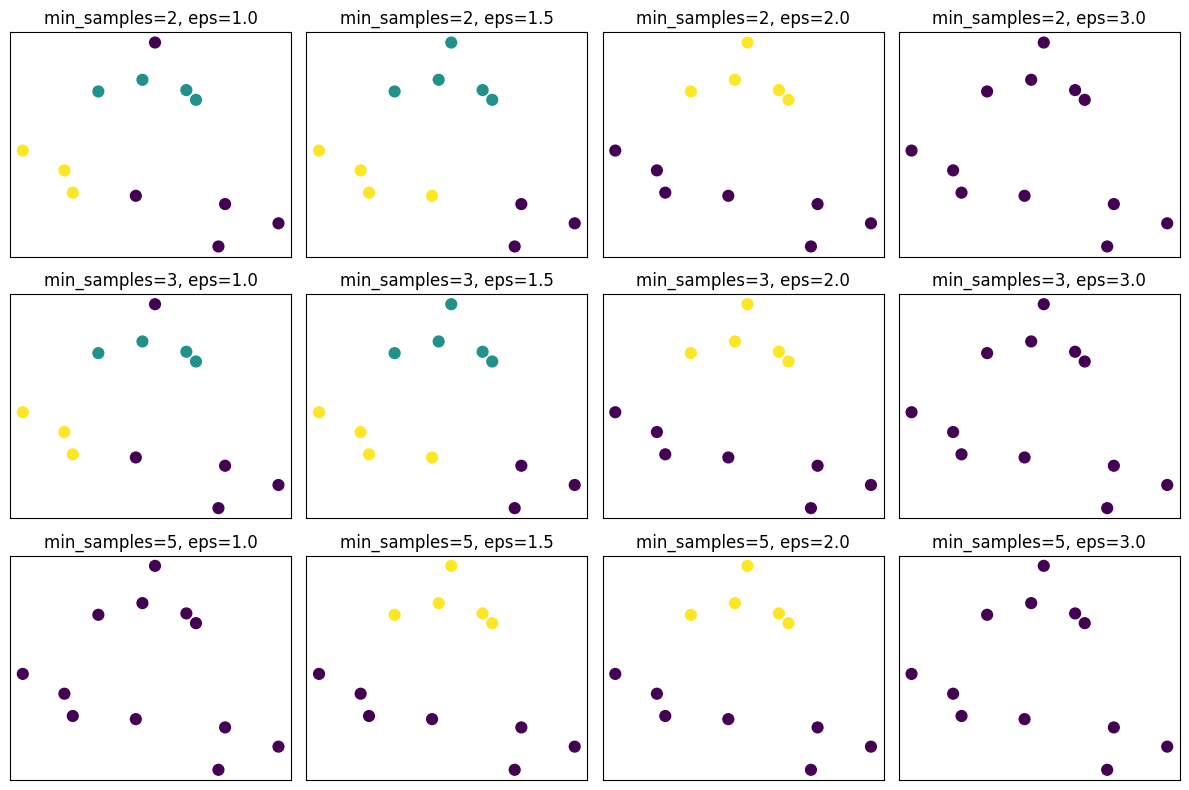

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from itertools import product
from sklearn.datasets import make_blobs

# synthetic dataset
X, y = make_blobs(random_state=0, n_samples=12)

min_samples_values = [2, 3, 5]
eps_values = [1.0, 1.5, 2.0, 3.0]

fig, axes = plt.subplots(
    len(min_samples_values),
    len(eps_values),
    figsize=(12, 8),
    subplot_kw={"xticks": (), "yticks": ()}
)

for ax, (min_samples, eps) in zip(axes.ravel(), product(min_samples_values, eps_values)):

    dbscan = DBSCAN(min_samples=min_samples, eps=eps)
    labels = dbscan.fit_predict(X)

    ax.scatter(X[:,0], X[:,1], c=labels, s=60)
    ax.set_title(f"min_samples={min_samples}, eps={eps}")

plt.tight_layout()
plt.show()



# Standardization and DBSCAN

DBSCAN relies on **distance calculations** to define neighborhoods.

Because of this, the **scale of the data affects clustering results**.

If features have very different ranges, the feature with the largest scale can dominate the distance calculation.

Example:

| Feature | Range |
|-------|-------|
| age | 0–100 |
| income | 0–100000 |

In Euclidean distance, income would dominate the distance calculation.

Standardization rescales the data to

- mean = 0
- variance = 1

so that each feature contributes more equally.

---

## Important Note

For the **two-moons dataset**, the feature scales are already similar.  
Therefore, scaling is **not strictly required**.

However, scaling changes the **overall distance scale of the dataset**.

Since DBSCAN uses a fixed radius parameter `eps`, standardization can make the default parameter values more appropriate.

In practice, scaling often makes DBSCAN more stable across datasets.


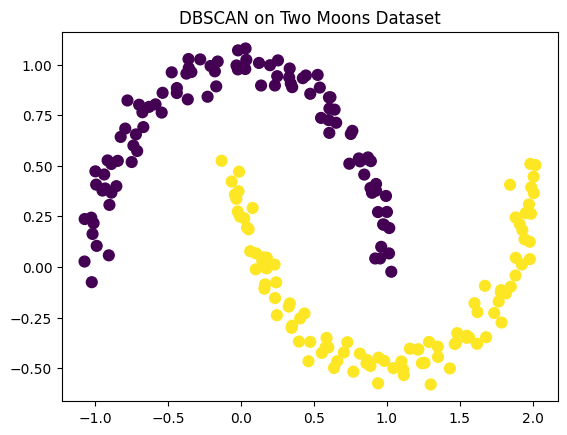

In [1]:

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# generate dataset
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN clustering
dbscan = DBSCAN()
clusters = dbscan.fit_predict(X_scaled)

# visualize result
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=60)
plt.title("DBSCAN on Two Moons Dataset")
plt.show()



# Key Takeaways

- DBSCAN is a **density-based clustering algorithm**
- Clusters correspond to **dense regions of points**
- Points are categorized as **core, border, or noise**
- The algorithm depends heavily on two parameters:
  - `eps`
  - `min_samples`
- Unlike k-means, DBSCAN **does not require specifying the number of clusters**
- Standardization often helps because DBSCAN is **distance-based**
